In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset=pd.read_csv('Loans.csv')
dataset.head(3)

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT


In [3]:
dataset.shape

(32586, 13)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  object 
 3   home_ownership       32586 non-null  object 
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  object 
 6   loan_grade           32586 non-null  object 
 7   loan_amnt            32585 non-null  object 
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11849 non-null  object 
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32582 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 3.2+ MB


In [5]:
dataset.describe()

,customer_id,customer_age,employment_duration,loan_int_rate,term_years,cred_hist_length
count,32583.000000,32586.000000,31691.000000,29470.000000,32586.000000,32586.000000
mean,16289.497806,27.732769,4.790161,11.011553,4.761738,5.804026
std,9405.919628,6.360528,4.142746,3.240440,2.471107,4.055078
min,1.000000,3.000000,0.000000,5.420000,1.000000,2.000000
25%,8144.500000,23.000000,2.000000,7.900000,3.000000,3.000000
50%,16288.000000,26.000000,4.000000,10.990000,4.000000,4.000000
75%,24433.500000,30.000000,7.000000,13.470000,7.000000,8.000000
max,32581.000000,144.000000,123.000000,23.220000,10.000000,30.000000


Detect Outliers

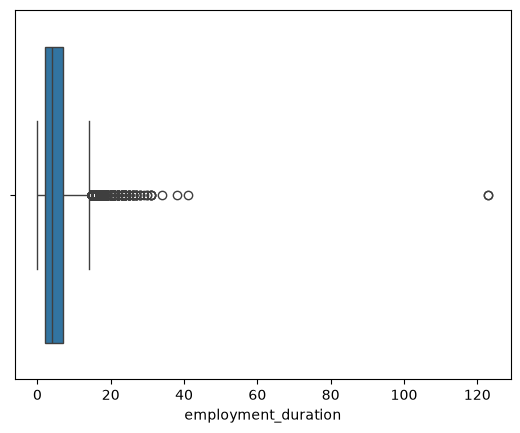

In [6]:
sns.boxplot(x="employment_duration",data=dataset)
plt.show()

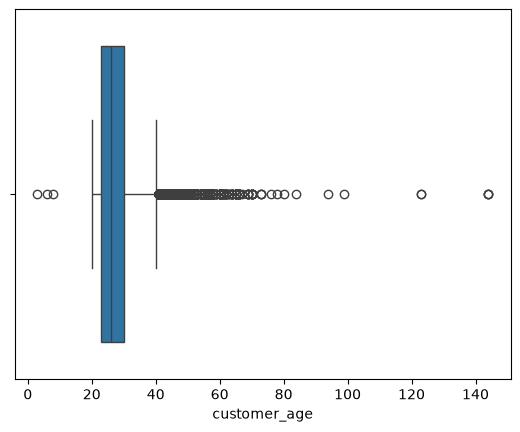

In [9]:
sns.boxplot(x="customer_age",data=dataset)
plt.show()

Remove Outliers

In [10]:
#IQR Method
dataset.shape

(32586, 13)

In [ ]:
q1=dataset["customer_age"].quantile(0.25)
q3=dataset["customer_age"].quantile(0.75)


np.float64(30.0)

In [13]:
IQR=q3-q1

In [14]:
min_range=q1-(1.5*IQR)
max_range=q3+(1.5*IQR)
min_range,max_range

(np.float64(12.5), np.float64(40.5))

In [16]:
new_dataset=dataset[dataset["customer_age"]<max_range]
new_dataset

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32295,32291.0,37,90000,MORTGAGE,11.0,DEBTCONSOLIDATION,A,"£4,000.00",6.62,7,N,15,NO DEFAULT
32297,32293.0,38,200000,MORTGAGE,0.0,DEBTCONSOLIDATION,A,"£3,000.00",7.68,8,N,12,NO DEFAULT
32298,32294.0,38,110000,MORTGAGE,5.0,MEDICAL,B,"£16,000.00",11.99,8,N,13,NO DEFAULT
32299,32295.0,36,92000,MORTGAGE,18.0,DEBTCONSOLIDATION,A,"£4,000.00",7.29,6,N,13,NO DEFAULT


In [17]:
new_dataset.shape

(31091, 13)

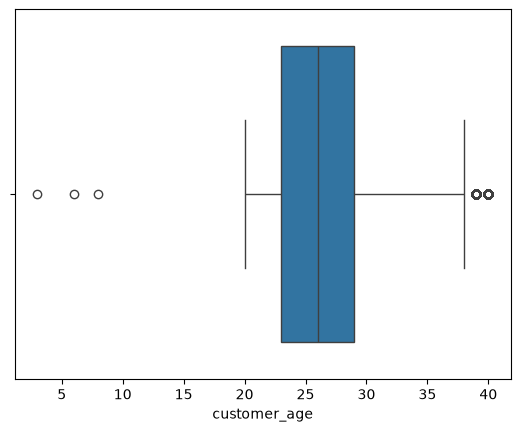

In [19]:
sns.boxplot(x="customer_age",data=new_dataset)
plt.show()

In [ ]:
#Remove Outlier Normal Method
dataset=pd.read_csv('Loans.csv')
dataset.head(3)

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT


In [24]:
dataset.isnull().sum()
dataset=dataset.ffill()
dataset.isnull().sum()

customer_id            0
customer_age           0
customer_income        0
home_ownership         0
employment_duration    0
loan_intent            0
loan_grade             0
loan_amnt              0
loan_int_rate          0
term_years             0
historical_default     0
cred_hist_length       0
Current_loan_status    0
dtype: int64

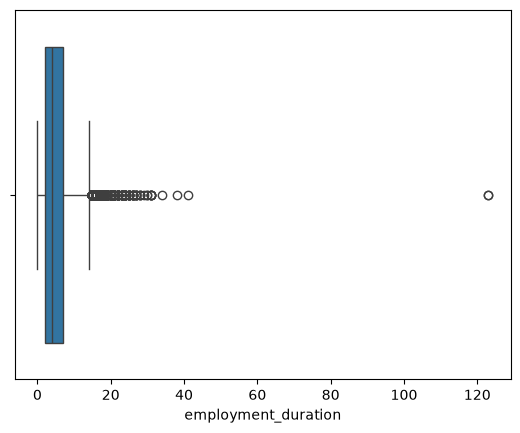

In [26]:
sns.boxplot(x="employment_duration",data=dataset)
plt.show()

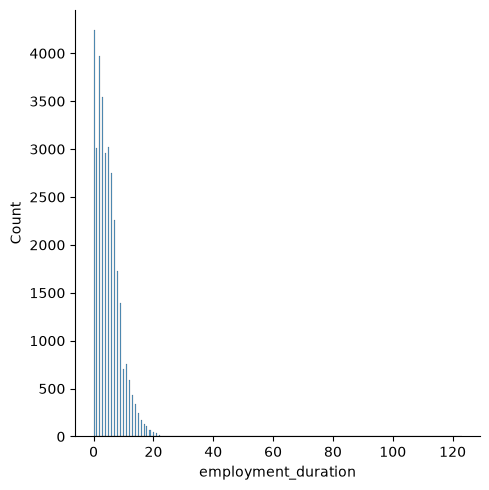

In [27]:
sns.displot(dataset["employment_duration"])

In [40]:
min_range=dataset["employment_duration"].mean()-(3*dataset["employment_duration"].std())
max_range=dataset["employment_duration"].mean()+(3*dataset["employment_duration"].std())

In [41]:
min_range,max_range

(np.float64(-7.636822701713745), np.float64(17.194669629842387))

In [42]:
new_dataset=dataset[dataset["employment_duration"]<=max_range]

<Axes: xlabel='employment_duration'>

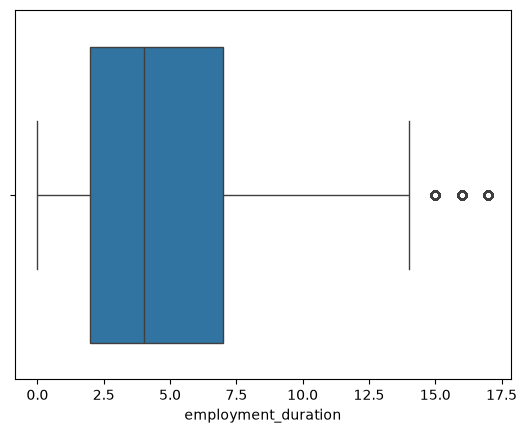

In [43]:
sns.boxplot(x="employment_duration",data=new_dataset)

In [44]:
#Remove Outlier using Z-score
z_score=(dataset["employment_duration"]-dataset["employment_duration"].mean())/(dataset["employment_duration"].std())


In [45]:
dataset["z_score"]=z_score

In [47]:
new_dataset.shape

(32258, 14)

In [48]:
dataset[dataset["z_score"]<3]

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,z_score
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,Y,2,NO DEFAULT,0.053418
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT,-0.913096
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT,-0.188210
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT,0.778304
5,6.0,21,9900,OWN,2.0,VENTURE,A,"£2,500.00",7.14,1,N,2,DEFAULT,-0.671468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32581,32577.0,57,53000,MORTGAGE,1.0,PERSONAL,C,"£5,800.00",13.16,7,Y,30,NO DEFAULT,-0.913096
32582,32578.0,54,120000,MORTGAGE,4.0,PERSONAL,A,"£17,625.00",7.49,4,Y,19,NO DEFAULT,-0.188210
32583,32579.0,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,"£35,000.00",10.99,5,N,28,DEFAULT,-0.429839
32584,32580.0,56,150000,MORTGAGE,5.0,PERSONAL,B,"£15,000.00",11.48,6,N,26,NO DEFAULT,0.053418
